In [118]:
import warnings
warnings.filterwarnings('ignore')
# step 1: Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
#for sklearn library installation - (pip install scikit-learn) at command prompt
#these are all classes which we import in sklearn library 
from sklearn.model_selection import train_test_split  # break into training and test data
from sklearn.impute import SimpleImputer   #replace the missing values
from sklearn.preprocessing import OneHotEncoder, StandardScaler #for performing encoding and standardscaling
from sklearn.compose import ColumnTransformer  # one col to multiple col --> Categorical value 
from sklearn.base import BaseEstimator, TransformerMixin  #for outliers
from sklearn.decomposition import PCA #for picking up right no. of features
from sklearn.pipeline import Pipeline #for putting all the preprocessing things together we will need pipeline so the data comes one by one piipeline will apply all the concepts  ---keeeping change the data
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # to evaluate regression problem we use metrics mae mse r square
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [121]:
#Load csv data to pandas dataframe
df = pd.read_csv(r"C:\Heart Disease Dataset\Heart Disease Dataset _payal.csv")
print(df)


       Patient_ID  Age  Gender  Height_cm  Weight_kg   BMI  Waist_cm  Smoking  \
0               1   66    Male        175         86  28.1        73        0   
1               2   48    Male        187         81  23.2       119        0   
2               3   68    Male        181         71  21.7       123        1   
3               4   41    Male        175         70  22.9       110        0   
4               5   76  Female        156         75  30.8        78        0   
...           ...  ...     ...        ...        ...   ...       ...      ...   
39995       39996   87    Male        186        117  33.8       112        1   
39996       39997   90  Female        153        112  47.8       102        0   
39997       39998   28  Female        177         70  22.3        66        0   
39998       39999   61    Male        152         98  42.4        70        1   
39999       40000   38    Male        177         88  28.1       108        1   

       Alcohol  PhysicalAct

In [90]:
df.head()


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
0,1,66,Male,175,86,28.1,73,0,0,0,...,0.9,1,14313,73,4,84,3,167,26.8,0
1,2,48,Male,187,81,23.2,119,0,1,3,...,1.0,1,15246,97,2,57,16,224,14.9,0
2,3,68,Male,181,71,21.7,123,1,0,0,...,1.2,1,11572,41,3,81,1,121,33.0,0
3,4,41,Male,175,70,22.9,110,0,1,1,...,1.4,0,8243,108,1,79,28,296,21.8,0
4,5,76,Female,156,75,30.8,78,0,0,4,...,1.2,0,13219,34,15,79,15,257,19.4,0


In [91]:
df.tail()


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
39995,39996,87,Male,186,117,33.8,112,1,0,0,...,2.0,1,5879,45,12,90,17,217,35.7,1
39996,39997,90,Female,153,112,47.8,102,0,1,3,...,3.4,1,672,61,7,92,23,160,23.3,1
39997,39998,28,Female,177,70,22.3,66,0,1,2,...,3.9,1,4377,57,1,61,15,109,24.5,1
39998,39999,61,Male,152,98,42.4,70,1,0,1,...,4.6,0,1385,57,7,79,9,115,12.1,1
39999,40000,38,Male,177,88,28.1,108,1,0,3,...,3.9,1,3527,68,0,59,27,279,26.6,1


In [7]:
 # no. of rows and columns in dataset 
print("Shape: ", df.shape)


Shape:  (40000, 45)


In [92]:
#data types 
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 45 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            40000 non-null  int64  
 1   Age                   40000 non-null  int64  
 2   Gender                40000 non-null  str    
 3   Height_cm             40000 non-null  int64  
 4   Weight_kg             40000 non-null  int64  
 5   BMI                   40000 non-null  float64
 6   Waist_cm              40000 non-null  int64  
 7   Smoking               40000 non-null  int64  
 8   Alcohol               40000 non-null  int64  
 9   PhysicalActivity      40000 non-null  int64  
 10  DietScore             40000 non-null  int64  
 11  SleepHours            40000 non-null  float64
 12  StressLevel           40000 non-null  int64  
 13  FamilyHistory         40000 non-null  int64  
 14  Diabetes              40000 non-null  int64  
 15  Hypertension          40000 no

In [29]:
print("Columns:\n",df.columns.tolist())

Columns:
 ['Patient_ID', 'Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_cm', 'Smoking', 'Alcohol', 'PhysicalActivity', 'DietScore', 'SleepHours', 'StressLevel', 'FamilyHistory', 'Diabetes', 'Hypertension', 'KidneyDisease', 'StrokeHistory', 'SystolicBP', 'DiastolicBP', 'RestingHR', 'RespRate', 'BodyTemp_C', 'SpO2', 'TotalChol', 'HDL', 'LDL', 'Triglycerides', 'FBS', 'HbA1c', 'Creatinine', 'RestingECG', 'ChestPainType', 'ExerciseAngina', 'MaxHR', 'Oldpeak', 'STSlope', 'DailySteps', 'HRV', 'WearableECGAlerts', 'MedicationAdherence', 'RemoteMonitoringFreq', 'AQIExposure', 'AvgTempExposure', 'HeartDisease']


In [122]:
#Checking for missing values sum them ,sort them 
print("Missing values:\n",df.isnull().sum().sort_values(ascending=False).head(30))

Missing values:
 Patient_ID          0
Age                 0
Gender              0
Height_cm           0
Weight_kg           0
BMI                 0
Waist_cm            0
Smoking             0
Alcohol             0
PhysicalActivity    0
DietScore           0
SleepHours          0
StressLevel         0
FamilyHistory       0
Diabetes            0
Hypertension        0
KidneyDisease       0
StrokeHistory       0
SystolicBP          0
DiastolicBP         0
RestingHR           0
RespRate            0
BodyTemp_C          0
SpO2                0
TotalChol           0
HDL                 0
LDL                 0
Triglycerides       0
FBS                 0
HbA1c               0
dtype: int64


In [94]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient_ID,40000.0,20000.500000,11547.149720,1.0,10000.75,20000.50,30000.25,40000.0
Age,40000.0,57.434850,19.105534,25.0,41.00,58.00,74.00,90.0
Height_cm,40000.0,169.991425,11.794922,150.0,160.00,170.00,180.00,190.0
Weight_kg,40000.0,79.959425,19.321428,45.0,66.00,79.00,92.00,120.0
BMI,40000.0,28.082963,7.914967,12.5,22.10,27.20,33.20,53.3
Waist_cm,40000.0,97.389000,19.045755,65.0,81.00,97.00,114.00,130.0
Smoking,40000.0,0.413500,0.492467,0.0,0.00,0.00,1.00,1.0
Alcohol,40000.0,0.500025,0.500006,0.0,0.00,1.00,1.00,1.0
PhysicalActivity,40000.0,1.990375,1.413305,0.0,1.00,2.00,3.00,4.0
DietScore,40000.0,5.479850,2.878628,1.0,3.00,5.00,8.00,10.0


In [95]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
39995    False
39996    False
39997    False
39998    False
39999    False
Length: 40000, dtype: bool

In [123]:
df.duplicated().sum()

np.int64(0)

In [124]:
#Missing Values
df.dropna()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
0,1,66,Male,175,86,28.1,73,0,0,0,...,0.9,1,14313,73,4,84,3,167,26.8,0
1,2,48,Male,187,81,23.2,119,0,1,3,...,1.0,1,15246,97,2,57,16,224,14.9,0
2,3,68,Male,181,71,21.7,123,1,0,0,...,1.2,1,11572,41,3,81,1,121,33.0,0
3,4,41,Male,175,70,22.9,110,0,1,1,...,1.4,0,8243,108,1,79,28,296,21.8,0
4,5,76,Female,156,75,30.8,78,0,0,4,...,1.2,0,13219,34,15,79,15,257,19.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39996,87,Male,186,117,33.8,112,1,0,0,...,2.0,1,5879,45,12,90,17,217,35.7,1
39996,39997,90,Female,153,112,47.8,102,0,1,3,...,3.4,1,672,61,7,92,23,160,23.3,1
39997,39998,28,Female,177,70,22.3,66,0,1,2,...,3.9,1,4377,57,1,61,15,109,24.5,1
39998,39999,61,Male,152,98,42.4,70,1,0,1,...,4.6,0,1385,57,7,79,9,115,12.1,1


In [125]:
df['Gender']=df['Gender'].replace(['Male','Female'],[1,0])
df


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure,HeartDisease
0,1,66,1,175,86,28.1,73,0,0,0,...,0.9,1,14313,73,4,84,3,167,26.8,0
1,2,48,1,187,81,23.2,119,0,1,3,...,1.0,1,15246,97,2,57,16,224,14.9,0
2,3,68,1,181,71,21.7,123,1,0,0,...,1.2,1,11572,41,3,81,1,121,33.0,0
3,4,41,1,175,70,22.9,110,0,1,1,...,1.4,0,8243,108,1,79,28,296,21.8,0
4,5,76,0,156,75,30.8,78,0,0,4,...,1.2,0,13219,34,15,79,15,257,19.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39996,87,1,186,117,33.8,112,1,0,0,...,2.0,1,5879,45,12,90,17,217,35.7,1
39996,39997,90,0,153,112,47.8,102,0,1,3,...,3.4,1,672,61,7,92,23,160,23.3,1
39997,39998,28,0,177,70,22.3,66,0,1,2,...,3.9,1,4377,57,1,61,15,109,24.5,1
39998,39999,61,1,152,98,42.4,70,1,0,1,...,4.6,0,1385,57,7,79,9,115,12.1,1


In [126]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]



In [127]:
df_input= df.drop(columns=['HeartDisease'])
df_output=df['HeartDisease']

df_output.value_counts()


HeartDisease
0    20000
1     9978
Name: count, dtype: int64

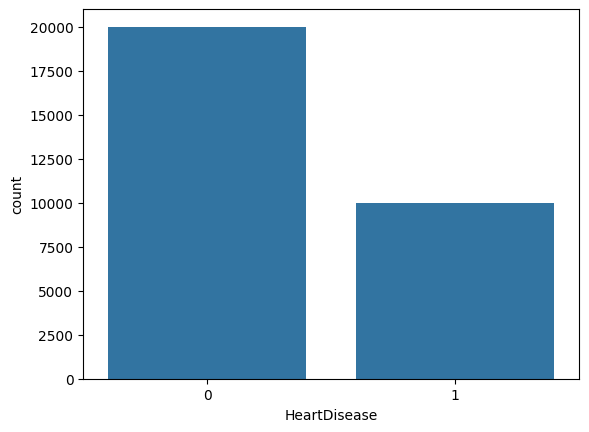

In [128]:
sns.countplot(x="HeartDisease", data=df)
plt.show()

In [129]:
x_train,x_test,y_train,y_test=train_test_split(df_input,df_output,test_size=0.2,random_state=1)


In [130]:
x_train

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,MaxHR,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure
17997,17998,35,1,185,78,22.8,69,0,0,2,...,130,1.1,0,10579,115,3,51,15,35,30.2
8555,8556,40,1,178,48,15.1,112,1,1,3,...,157,0.4,1,12226,120,0,94,19,233,19.5
1552,1553,71,1,190,60,16.6,121,0,1,1,...,94,1.4,2,15426,80,11,53,29,188,23.2
26454,26455,66,1,161,91,35.1,95,0,0,0,...,161,5.8,1,5935,26,8,97,17,176,18.5
11769,11770,28,1,187,57,16.3,109,1,1,2,...,105,1.7,2,10523,82,9,67,0,43,19.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17289,17290,88,0,152,70,30.3,120,1,1,2,...,131,1.8,1,8553,111,13,90,20,109,36.8
5192,5193,74,1,162,85,32.4,113,1,0,4,...,105,0.1,2,13214,68,4,58,15,195,24.8
12172,12173,58,0,180,90,27.8,105,0,0,4,...,87,0.6,0,8130,97,12,90,30,212,31.8
235,236,45,0,180,68,21.0,127,1,0,2,...,99,0.2,2,10376,85,14,81,4,206,38.4


In [64]:
x_test

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Waist_cm,Smoking,Alcohol,PhysicalActivity,...,MaxHR,Oldpeak,STSlope,DailySteps,HRV,WearableECGAlerts,MedicationAdherence,RemoteMonitoringFreq,AQIExposure,AvgTempExposure
19035,19036,28,0,177,77,24.6,75,0,0,2,...,71,1.8,2,10103,82,11,84,28,139,27.1
4236,4237,45,0,168,83,29.4,108,0,0,1,...,93,0.1,1,11755,72,13,100,3,161,28.2
827,828,26,1,182,66,19.9,78,0,1,2,...,178,0.7,0,10690,66,6,51,15,207,15.9
9779,9780,25,0,175,49,16.0,126,0,1,4,...,193,1.5,2,11375,65,13,89,0,279,25.0
9541,9542,79,1,151,62,27.2,93,0,1,4,...,168,1.1,2,6752,97,7,56,17,208,18.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5626,5627,25,0,190,89,24.7,119,0,1,2,...,130,1.7,2,10165,84,2,55,13,298,20.0
19859,19860,45,1,176,86,27.8,77,1,0,2,...,73,1.0,1,12622,38,7,50,8,102,35.2
8123,8124,62,0,171,79,27.0,111,0,0,1,...,187,0.4,2,8134,61,1,72,15,247,31.1
844,845,84,0,182,65,19.6,112,0,1,0,...,196,0.6,1,14782,69,3,81,16,218,36.7


In [131]:
y_train

17997    0
8555     0
1552     0
26454    1
11769    0
        ..
17289    0
5192     0
12172    0
235      0
39504    1
Name: HeartDisease, Length: 23982, dtype: int64

In [132]:
y_test

18894    0
3018     0
28233    1
2782     0
17856    0
        ..
4163     0
9368     0
30488    1
23335    1
14438    0
Name: HeartDisease, Length: 5996, dtype: int64

In [133]:
model = LogisticRegression()
model.fit(x_train,y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [134]:
model.score(x_test,y_test)

1.0

In [135]:
y_pred = model.predict(x_test)


In [136]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Report:\n", classification_report(y_test, y_pred))


Accuracy: 1.0
Confusion Matrix:
 [[4073    0]
 [   0 1923]]
Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4073
           1       1.00      1.00      1.00      1923

    accuracy                           1.00      5996
   macro avg       1.00      1.00      1.00      5996
weighted avg       1.00      1.00      1.00      5996



In [137]:
# KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)
y_pred_knn = knn.predict(x_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.9998332221480988


In [139]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=1)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0


In [140]:
# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 1.0


In [141]:
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)

print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R² Score:", r2_score(y_test, y_pred_lr))

MSE: 0.008944325801997128
MAE: 0.07412125204724644
R² Score: 0.9589439499362054


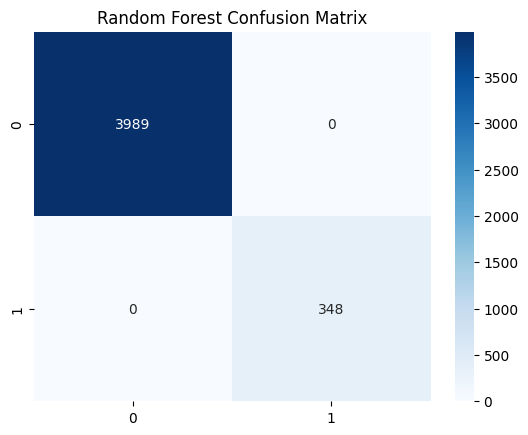

In [73]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [142]:
# Collect results from classification models
results = {
    "KNN Accuracy": accuracy_score(y_test, y_pred_knn),
    "Decision Tree Accuracy": accuracy_score(y_test, y_pred_dt),
    "Random Forest Accuracy": accuracy_score(y_test, y_pred_rf),
}

# If you also ran regression (Linear Regression)
results_reg = {
    "Linear Regression MSE": mean_squared_error(y_test, y_pred_lr),
    "Linear Regression MAE": mean_absolute_error(y_test, y_pred_lr),
    "Linear Regression R²": r2_score(y_test, y_pred_lr),
}
# Convert to DataFrame for a clean table
df_results = pd.DataFrame([results])
df_results_reg = pd.DataFrame([results_reg])

print("📊 Classification Results")
print(df_results)

print("\n📈 Regression Results")
print(df_results_reg)

📊 Classification Results
   KNN Accuracy  Decision Tree Accuracy  Random Forest Accuracy
0      0.999833                     1.0                     1.0

📈 Regression Results
   Linear Regression MSE  Linear Regression MAE  Linear Regression R²
0               0.008944               0.074121              0.958944


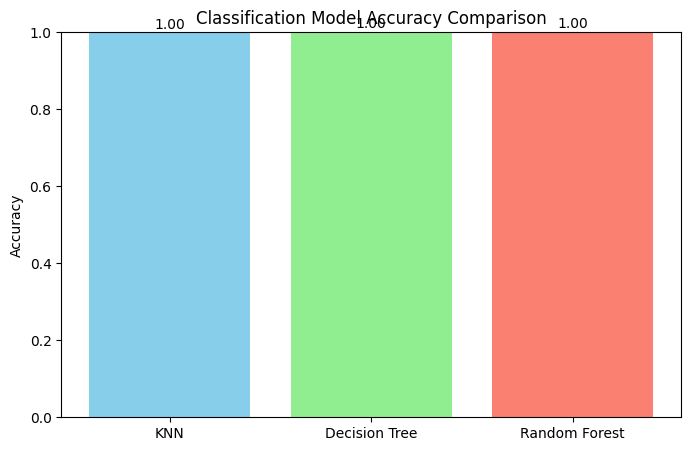

In [143]:
# Collect accuracies
model_names = ["KNN", "Decision Tree", "Random Forest"]
accuracies = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

# Plot
plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies, color=['skyblue','lightgreen','salmon'])
plt.title("Classification Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
for i, v in enumerate(accuracies):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')
plt.show()

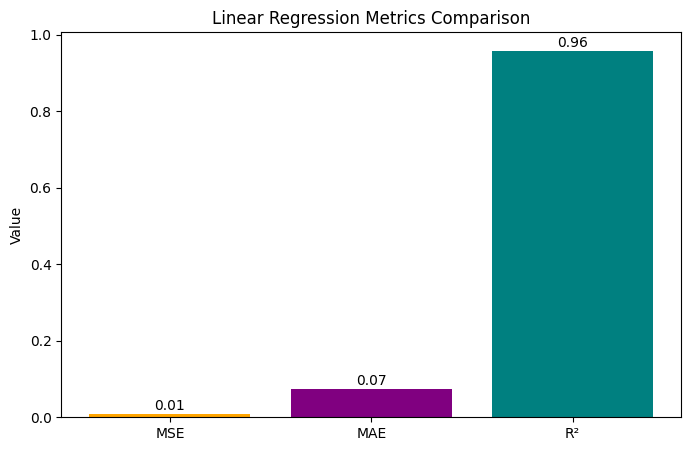

In [144]:
metrics = ["MSE", "MAE", "R²"]
values = [
    mean_squared_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_lr),
    r2_score(y_test, y_pred_lr)
]

plt.figure(figsize=(8,5))
plt.bar(metrics, values, color=['orange','purple','teal'])
plt.title("Linear Regression Metrics Comparison")
plt.ylabel("Value")
for i, v in enumerate(values):
    plt.text(i, v+0.01, f"{v:.2f}", ha='center')
plt.show()